# 02 — Probability Calibration

A reliability audit of the pre-tournament home/draw/away probabilities, including Brier score, log loss, classwise calibration curves, expected calibration error, and an out-of-fold multinomial recalibration experiment.

**Repository:** SambaSportAI World Cup 2026 Forecasting Pipeline  
**Execution:** Run from the repository root or directly from the `notebooks/` folder.  
**Reproducibility:** All inputs are read from version-controlled CSV/JSON artifacts in this repository.

In [1]:
from pathlib import Path
import json
import math
import ast
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)

def find_repo_root(start=None):
    start = Path(start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "pyproject.toml").exists() and (candidate / "data").exists():
            return candidate
    # Common fallback when launched from notebooks/ via Jupyter.
    fallback = Path.cwd().resolve().parent
    if (fallback / "pyproject.toml").exists():
        return fallback
    raise FileNotFoundError("Could not locate repository root. Launch Jupyter inside the repository.")

ROOT = find_repo_root()
print(f"Repository root: {ROOT}")

Repository root: /mnt/data/sambasportai-world-cup-2026


## 1. Load the match-level audit

In [2]:
from sklearn.metrics import log_loss
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GroupKFold

audit = pd.read_csv(ROOT / "outputs" / "evaluation" / "group_stage_prediction_vs_actual.csv")
outcomes = ["home_win", "draw", "away_win"]
prob_cols = ["p_home_win", "p_draw", "p_away_win"]
y = audit["actual_outcome"].map({name: i for i, name in enumerate(outcomes)}).to_numpy()
P = audit[prob_cols].to_numpy(float)
print(P.shape, audit.shape)

(72, 3) (72, 49)


## 2. Probability-scoring metrics

In [3]:
def multiclass_brier(y_true, probs, n_classes=3):
    one_hot = np.eye(n_classes)[y_true]
    return np.mean(np.sum((probs - one_hot) ** 2, axis=1))

def ranked_probability_score(y_true, probs):
    one_hot = np.eye(probs.shape[1])[y_true]
    return np.mean(np.sum((np.cumsum(probs, axis=1)[:, :-1] - np.cumsum(one_hot, axis=1)[:, :-1]) ** 2, axis=1) / (probs.shape[1] - 1))

raw_metrics = pd.Series({
    "accuracy": (P.argmax(axis=1) == y).mean(),
    "log_loss": log_loss(y, P, labels=[0, 1, 2]),
    "multiclass_brier": multiclass_brier(y, P),
    "ranked_probability_score": ranked_probability_score(y, P),
}, name="raw_probabilities")
display(raw_metrics.to_frame())

,raw_probabilities
accuracy,0.597222
log_loss,0.879911
multiclass_brier,0.520571
ranked_probability_score,0.159352


## 3. Classwise reliability diagrams

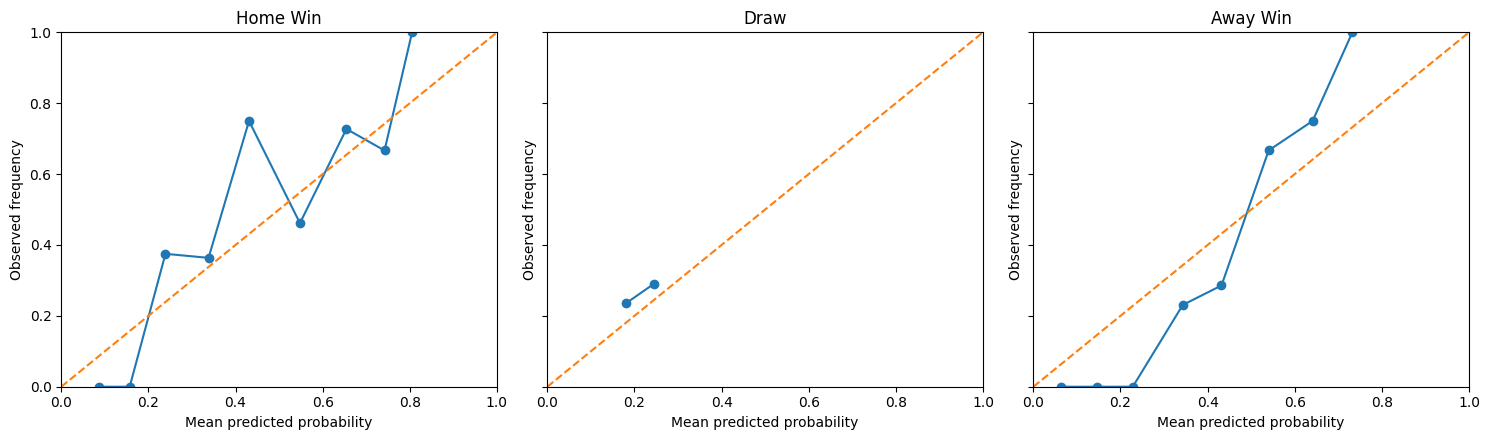

### Home Win

,bin,count,mean_predicted,observed_rate
0,"(-0.001, 0.1]",2,0.086,0.000
1,"(0.1, 0.2]",11,0.157,0.000
2,"(0.2, 0.3]",8,0.239,0.375
3,"(0.3, 0.4]",11,0.338,0.364
4,"(0.4, 0.5]",8,0.431,0.750
5,"(0.5, 0.6]",13,0.548,0.462
6,"(0.6, 0.7]",11,0.655,0.727
7,"(0.7, 0.8]",6,0.742,0.667
8,"(0.8, 0.9]",2,0.805,1.000
9,"(0.9, 1.0]",0,NaN,NaN


### Draw

,bin,count,mean_predicted,observed_rate
0,"(-0.001, 0.1]",0,NaN,NaN
1,"(0.1, 0.2]",17,0.180,0.235
2,"(0.2, 0.3]",55,0.245,0.291
3,"(0.3, 0.4]",0,NaN,NaN
4,"(0.4, 0.5]",0,NaN,NaN
5,"(0.5, 0.6]",0,NaN,NaN
6,"(0.6, 0.7]",0,NaN,NaN
7,"(0.7, 0.8]",0,NaN,NaN
8,"(0.8, 0.9]",0,NaN,NaN
9,"(0.9, 1.0]",0,NaN,NaN


### Away Win

,bin,count,mean_predicted,observed_rate
0,"(-0.001, 0.1]",6,0.063,0.000
1,"(0.1, 0.2]",17,0.146,0.000
2,"(0.2, 0.3]",10,0.228,0.000
3,"(0.3, 0.4]",13,0.343,0.231
4,"(0.4, 0.5]",7,0.432,0.286
5,"(0.5, 0.6]",9,0.540,0.667
6,"(0.6, 0.7]",8,0.641,0.750
7,"(0.7, 0.8]",2,0.732,1.000
8,"(0.8, 0.9]",0,NaN,NaN
9,"(0.9, 1.0]",0,NaN,NaN


In [4]:
def reliability_table(prob, observed, n_bins=10):
    frame = pd.DataFrame({"prob": prob, "observed": observed})
    # Fixed bins make diagrams comparable across classes.
    frame["bin"] = pd.cut(frame["prob"], bins=np.linspace(0, 1, n_bins + 1), include_lowest=True)
    return (
        frame.groupby("bin", observed=False)
        .agg(count=("observed", "size"), mean_predicted=("prob", "mean"), observed_rate=("observed", "mean"))
        .reset_index()
    )

reliability = {}
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharex=True, sharey=True)
for class_idx, (name, col, ax) in enumerate(zip(outcomes, prob_cols, axes)):
    table = reliability_table(audit[col], (y == class_idx).astype(int), n_bins=10)
    reliability[name] = table
    nonempty = table[table["count"] > 0]
    ax.plot(nonempty["mean_predicted"], nonempty["observed_rate"], marker="o")
    ax.plot([0, 1], [0, 1], linestyle="--")
    ax.set_title(name.replace("_", " ").title())
    ax.set_xlabel("Mean predicted probability")
    ax.set_ylabel("Observed frequency")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

for name, table in reliability.items():
    display(Markdown(f"### {name.replace('_', ' ').title()}"))
    display(table.round(3))

## 4. Expected calibration error

In [5]:
def top_label_ece(y_true, probs, n_bins=10):
    confidence = probs.max(axis=1)
    predicted = probs.argmax(axis=1)
    correct = (predicted == y_true).astype(float)
    bins = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    rows = []
    for lo, hi in zip(bins[:-1], bins[1:]):
        mask = (confidence >= lo) & (confidence < hi if hi < 1 else confidence <= hi)
        if not mask.any():
            continue
        conf = confidence[mask].mean()
        acc = correct[mask].mean()
        weight = mask.mean()
        ece += weight * abs(acc - conf)
        rows.append({"lower": lo, "upper": hi, "count": int(mask.sum()), "mean_confidence": conf, "accuracy": acc, "gap": acc-conf})
    return ece, pd.DataFrame(rows)

raw_ece, raw_ece_table = top_label_ece(y, P)
print(f"Top-label ECE: {raw_ece:.4f}")
display(raw_ece_table.round(3))

Top-label ECE: 0.0696


,lower,upper,count,mean_confidence,accuracy,gap
0,0.3,0.4,6,0.386,0.167,-0.220
1,0.4,0.5,15,0.431,0.533,0.102
2,0.5,0.6,22,0.545,0.545,0.001
3,0.6,0.7,19,0.649,0.737,0.088
4,0.7,0.8,8,0.740,0.750,0.010
5,0.8,0.9,2,0.805,1.000,0.195


## 5. Out-of-fold multinomial recalibration

To avoid evaluating a calibrator on the same matches used to fit it, the notebook uses **GroupKFold** with group labels. The calibrator receives only transformed model probabilities:

\[
x_k = \log(p_k + \epsilon)
\]

This is a compact multiclass analogue of logistic/Platt calibration. The experiment is diagnostic; it does not overwrite the released v9 checkpoint.

In [6]:
eps = 1e-8
X_cal = np.log(np.clip(P, eps, 1.0))
groups = audit["group"].to_numpy()

splitter = GroupKFold(n_splits=6)
P_oof = np.zeros_like(P)
fold_rows = []

for fold, (train_idx, test_idx) in enumerate(splitter.split(X_cal, y, groups=groups), start=1):
    calibrator = LogisticRegression(C=0.5, max_iter=2000)
    calibrator.fit(X_cal[train_idx], y[train_idx])
    P_oof[test_idx] = calibrator.predict_proba(X_cal[test_idx])
    fold_rows.append({
        "fold": fold,
        "test_groups": ", ".join(sorted(set(groups[test_idx]))),
        "matches": len(test_idx),
        "raw_log_loss": log_loss(y[test_idx], P[test_idx], labels=[0,1,2]),
        "calibrated_log_loss": log_loss(y[test_idx], P_oof[test_idx], labels=[0,1,2]),
    })

display(pd.DataFrame(fold_rows).round(4))

,fold,test_groups,matches,raw_log_loss,calibrated_log_loss
0,1,"F, L",12,0.8737,0.7611
1,2,"E, K",12,0.9254,0.8215
2,3,"D, J",12,0.8227,0.8423
3,4,"C, I",12,0.5837,0.6260
4,5,"B, H",12,1.0687,1.1277
5,6,"A, G",12,1.0052,0.9147


## 6. Raw versus calibrated metrics

In [7]:
calibrated_ece, calibrated_ece_table = top_label_ece(y, P_oof)
comparison = pd.DataFrame({
    "raw": {
        "accuracy": (P.argmax(axis=1) == y).mean(),
        "log_loss": log_loss(y, P, labels=[0,1,2]),
        "multiclass_brier": multiclass_brier(y, P),
        "ranked_probability_score": ranked_probability_score(y, P),
        "top_label_ece": raw_ece,
    },
    "oof_calibrated": {
        "accuracy": (P_oof.argmax(axis=1) == y).mean(),
        "log_loss": log_loss(y, P_oof, labels=[0,1,2]),
        "multiclass_brier": multiclass_brier(y, P_oof),
        "ranked_probability_score": ranked_probability_score(y, P_oof),
        "top_label_ece": calibrated_ece,
    }
})
display(comparison.round(4))

,raw,oof_calibrated
accuracy,0.5972,0.6111
log_loss,0.8799,0.8489
multiclass_brier,0.5206,0.5201
ranked_probability_score,0.1594,0.1567
top_label_ece,0.0696,0.0515


## 7. Compare calibration curves

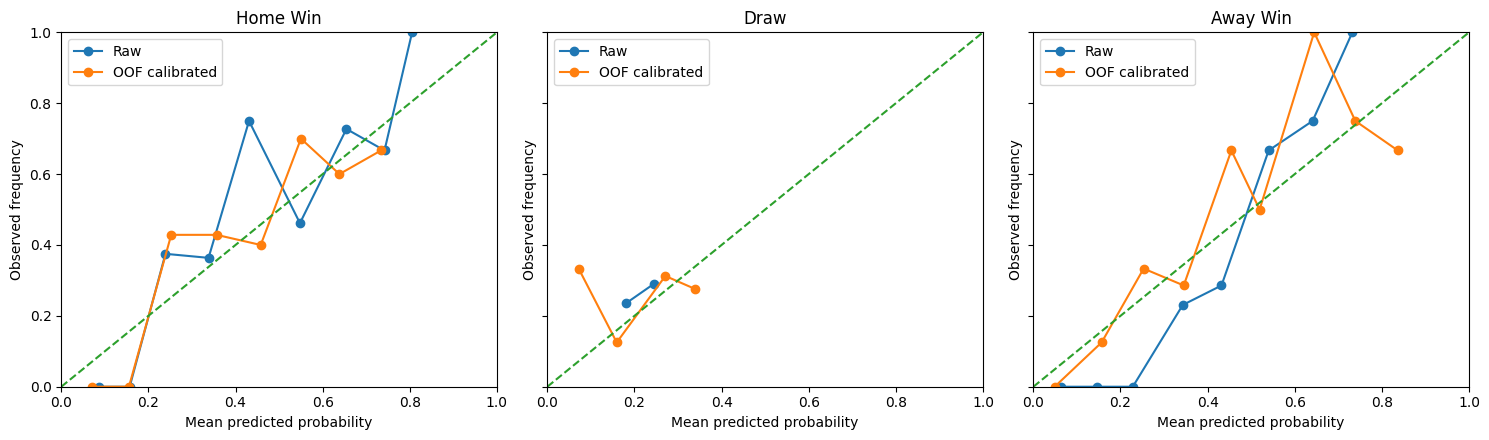

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharex=True, sharey=True)
for class_idx, (name, ax) in enumerate(zip(outcomes, axes)):
    raw_table = reliability_table(P[:, class_idx], (y == class_idx).astype(int))
    cal_table = reliability_table(P_oof[:, class_idx], (y == class_idx).astype(int))
    raw_nonempty = raw_table[raw_table["count"] > 0]
    cal_nonempty = cal_table[cal_table["count"] > 0]
    ax.plot(raw_nonempty["mean_predicted"], raw_nonempty["observed_rate"], marker="o", label="Raw")
    ax.plot(cal_nonempty["mean_predicted"], cal_nonempty["observed_rate"], marker="o", label="OOF calibrated")
    ax.plot([0,1], [0,1], linestyle="--")
    ax.set_title(name.replace("_", " ").title())
    ax.set_xlabel("Mean predicted probability")
    ax.set_ylabel("Observed frequency")
    ax.set_xlim(0,1)
    ax.set_ylim(0,1)
    ax.legend()
plt.tight_layout()
plt.show()

## Interpretation

- Calibration can improve log loss without changing many argmax decisions.
- The draw class is the most important calibration challenge because the raw model rarely makes draw the largest probability.
- With only 72 observations, a calibrator should remain simple and regularized.
- The released prediction pipeline should only adopt a recalibration layer after group-held-out validation confirms an improvement.